In [3]:
import os
import numpy as np
import rasterio
import scipy.stats as stats
import matplotlib.pyplot as plt
from pathlib import Path


PROJECT_ROOT = Path(os.getcwd()).resolve().parent
DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
NODATA = -9999.0

# Generate tracking timeline matrices
YEARS = list(range(2006, 2026))
MONTHS = [f"{m:02d}" for m in range(1, 13)]
TIME_STEPS = [f"{y}_{m}" for y in YEARS for m in MONTHS]

def load_processed_layer(filename: str) -> np.ndarray:
    filepath = PROCESSED_DIR / filename
    if not filepath.exists():
        raise FileNotFoundError(f"Missing layer: {filepath}. Run your trend script first.")
    with rasterio.open(filepath) as src:
        arr = src.read(1).astype(np.float32)
        arr[arr == src.nodata if src.nodata is not None else NODATA] = np.nan
        return arr

def load_raw_stack(pattern: str) -> np.ndarray:
    files = [DATA_DIR / pattern.format(step=ts) for ts in TIME_STEPS]
    with rasterio.open(files[0]) as src:
        rows, cols = src.height, src.width
    
    stack = np.full((len(TIME_STEPS), rows, cols), np.nan, dtype=np.float32)
    for i, f in enumerate(files):
        with rasterio.open(f) as src:
            data = src.read(1).astype(np.float32)
            nodata_val = src.nodata if src.nodata is not None else NODATA
            data[data == nodata_val] = np.nan
            stack[i] = data
    return stack

-- NDVI Trend Analysis
Mean Slope Magnitude: 0.000102 / month
Significant Greening Pixels (1):  4,298
Significant Browning Pixels (-1): 368
Stable/No Trend Pixels (0):       11,172


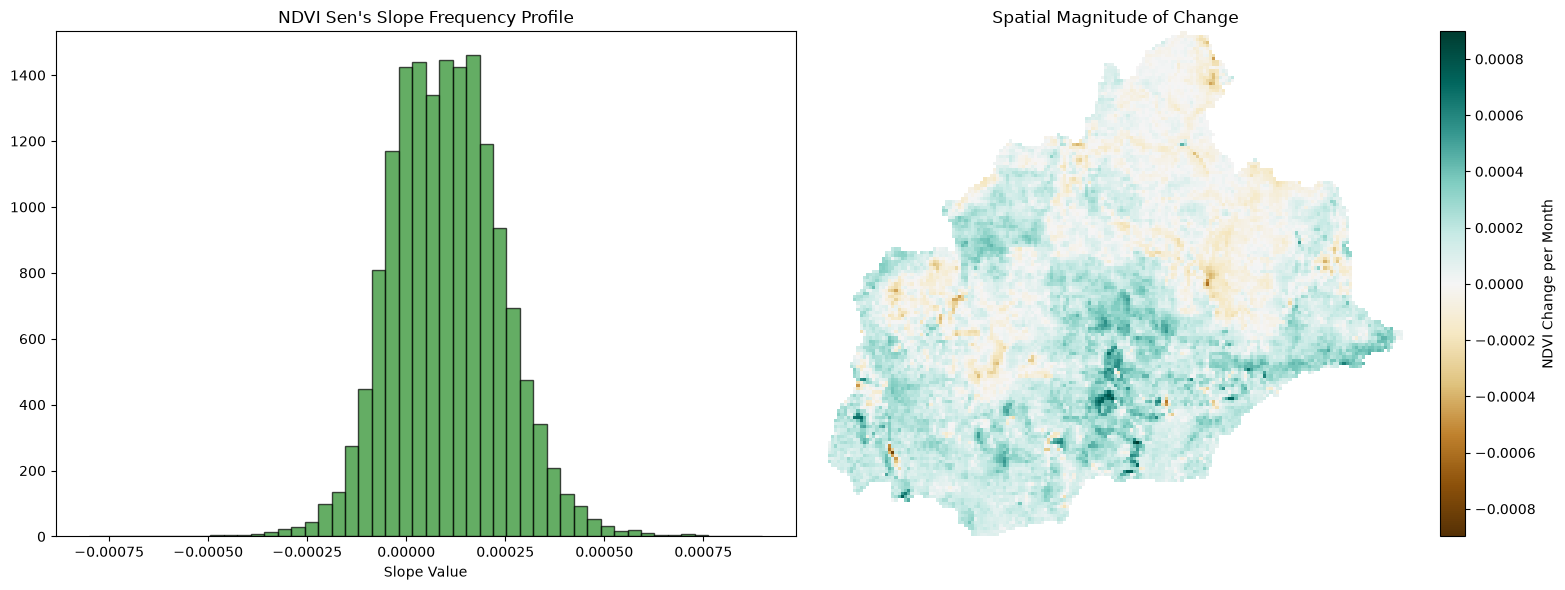

In [4]:
print("-- NDVI Trend Analysis")
ndvi_slope = load_processed_layer("ndvi_sens_slope.tif")
ndvi_trend = load_processed_layer("ndvi_mk_trend.tif")

print(f"Mean Slope Magnitude: {np.nanmean(ndvi_slope):.6f} / month")
print(f"Significant Greening Pixels (1):  {np.count_nonzero(ndvi_trend == 1):,}")
print(f"Significant Browning Pixels (-1): {np.count_nonzero(ndvi_trend == -1):,}")
print(f"Stable/No Trend Pixels (0):       {np.count_nonzero(ndvi_trend == 0):,}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
axes[0].hist(ndvi_slope[~np.isnan(ndvi_slope)], bins=50, color='forestgreen', alpha=0.7, edgecolor='black')
axes[0].set_title("NDVI Sen's Slope Frequency Profile")
axes[0].set_xlabel("Slope Value")

# Spatial Map Plotting
max_val = np.nanmax(np.abs(ndvi_slope))
im = axes[1].imshow(ndvi_slope, cmap="BrBG", vmin=-max_val, vmax=max_val)
axes[1].set_title("Spatial Magnitude of Change")
axes[1].axis("off")
fig.colorbar(im, ax=axes[1], orientation='vertical', label="NDVI Change per Month")

plt.tight_layout()
plt.show()

-- LST Metrics 
Mean Slope Magnitude: -0.010502 / month
Significant Warming Pixels (1):  0
Significant Cooling Pixels (-1): 15,838


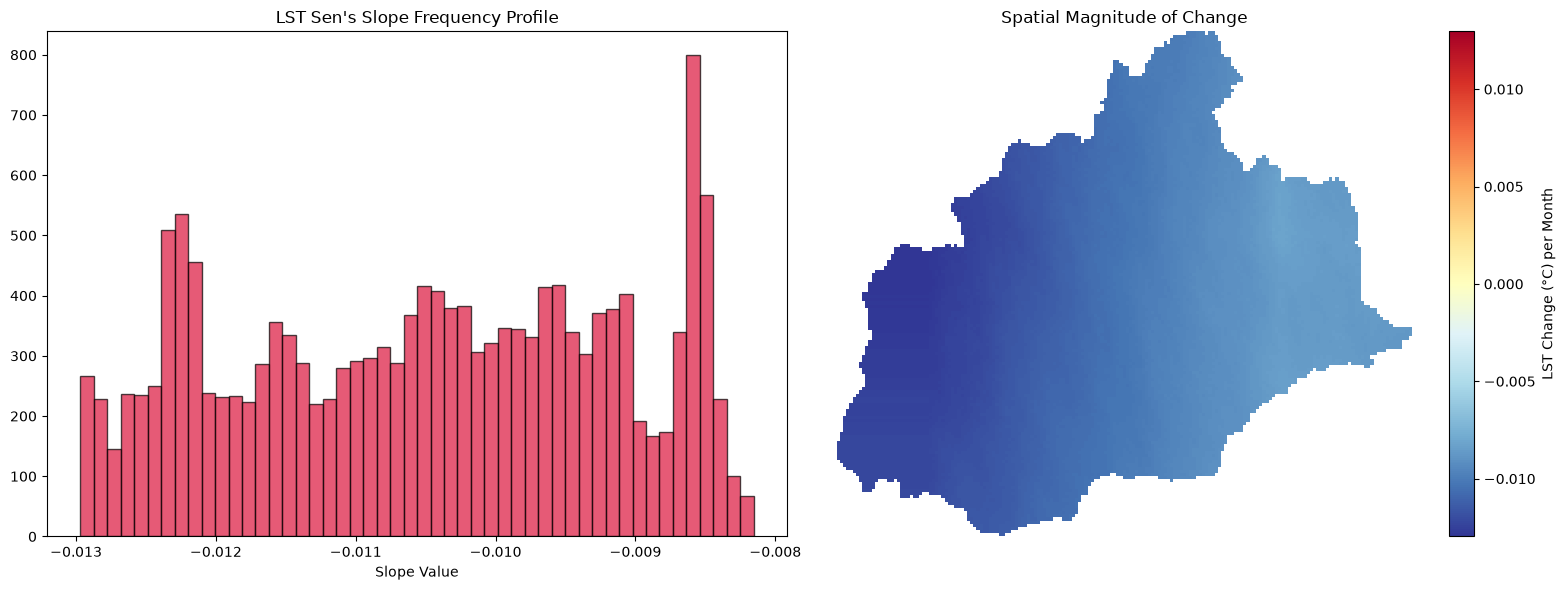

In [5]:
print("-- LST Metrics ")
lst_slope = load_processed_layer("lst_sens_slope.tif")
lst_trend = load_processed_layer("lst_mk_trend.tif")

print(f"Mean Slope Magnitude: {np.nanmean(lst_slope):.6f} / month")
print(f"Significant Warming Pixels (1):  {np.count_nonzero(lst_trend == 1):,}")
print(f"Significant Cooling Pixels (-1): {np.count_nonzero(lst_trend == -1):,}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
axes[0].hist(lst_slope[~np.isnan(lst_slope)], bins=50, color='crimson', alpha=0.7, edgecolor='black')
axes[0].set_title("LST Sen's Slope Frequency Profile")
axes[0].set_xlabel("Slope Value")

# Spatial Map
max_val_lst = np.nanmax(np.abs(lst_slope))
im_lst = axes[1].imshow(lst_slope, cmap="RdYlBu_r", vmin=-max_val_lst, vmax=max_val_lst)
axes[1].set_title("Spatial Magnitude of Change")
axes[1].axis("off")
fig.colorbar(im_lst, ax=axes[1], orientation='vertical', label="LST Change (°C) per Month")

plt.tight_layout()
plt.show()

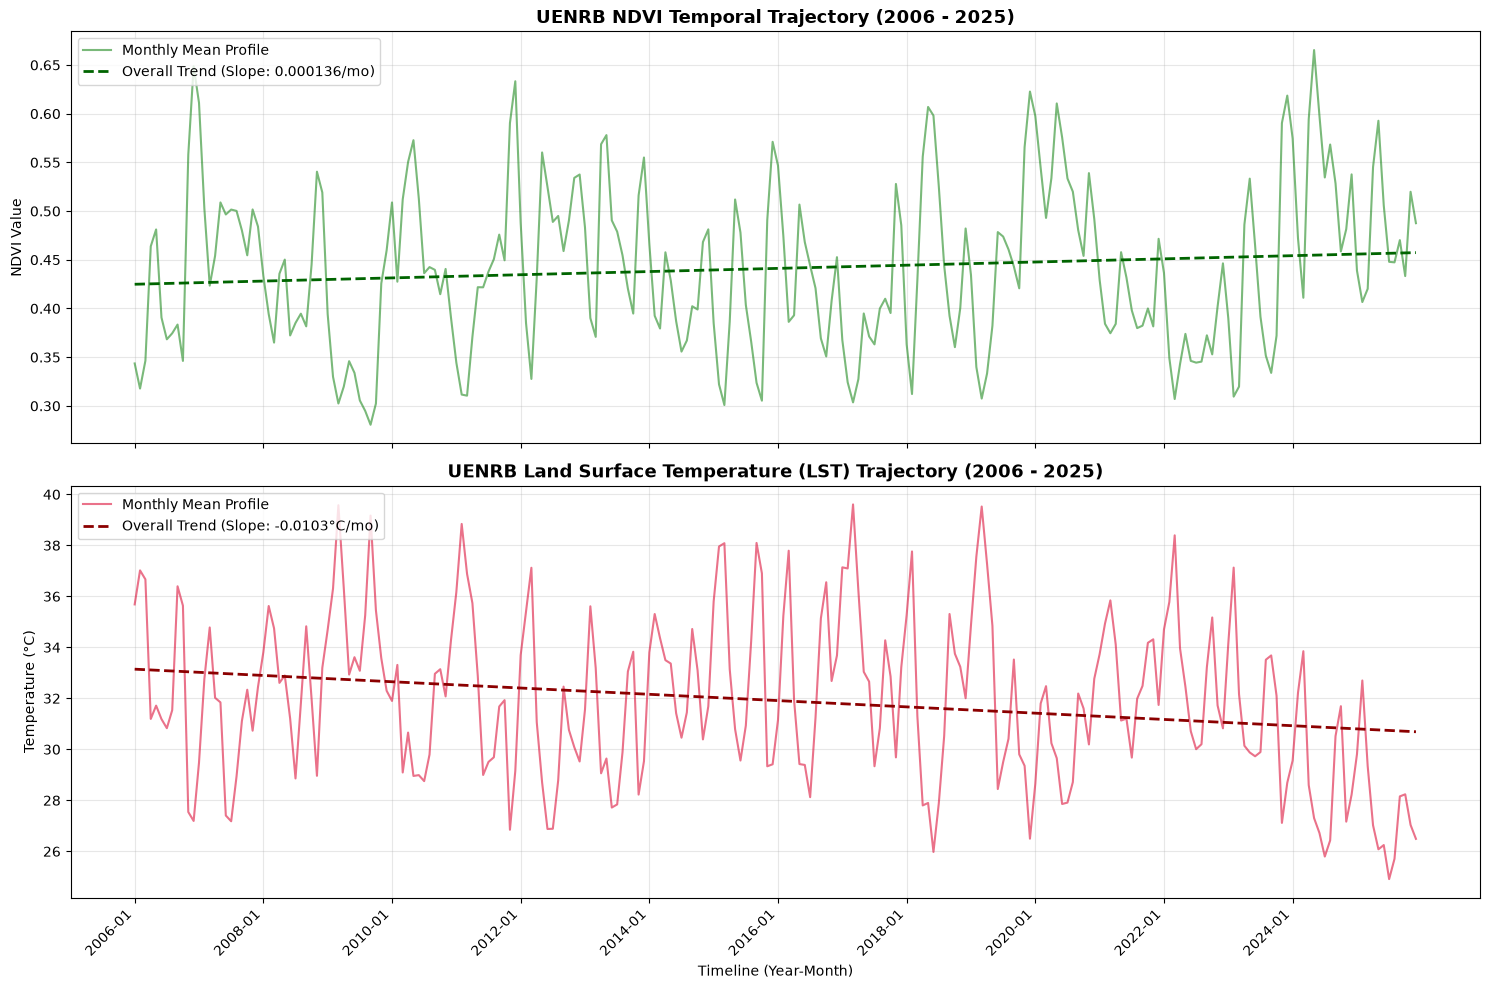

In [6]:

ndvi_stack = load_raw_stack("NDVI_{step}.tif")
lst_stack = load_raw_stack("LST_{step}.tif")

# Handle any minor boundary differences between variables safely for regional mean calculation
min_rows = min(ndvi_stack.shape[1], lst_stack.shape[1])
min_cols = min(ndvi_stack.shape[2], lst_stack.shape[2])

# Collapse 3D cubes to 1D regional timeline profiles
ndvi_regional_mean = np.array([np.nanmean(ndvi_stack[i][:min_rows, :min_cols]) for i in range(len(TIME_STEPS))])
lst_regional_mean = np.array([np.nanmean(lst_stack[i][:min_rows, :min_cols]) for i in range(len(TIME_STEPS))])

time_indices = np.arange(len(TIME_STEPS))
date_labels = [ts.replace("_", "-") for ts in TIME_STEPS]

# Fit linear trend guide lines
n_slope, n_incpt, _, _, _ = stats.linregress(time_indices, ndvi_regional_mean)
l_slope, l_incpt, _, _, _ = stats.linregress(time_indices, lst_regional_mean)

# Generate Dual Subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# 1. NDVI Subplot
ax1.plot(time_indices, ndvi_regional_mean, color='forestgreen', alpha=0.6, label='Monthly Mean Profile')
ax1.plot(time_indices, n_slope * time_indices + n_incpt, color='darkgreen', linestyle='--', linewidth=2,
         label=f"Overall Trend (Slope: {n_slope:.6f}/mo)")
ax1.set_title("UENRB NDVI Temporal Trajectory (2006 - 2025)", fontsize=13, fontweight='bold')
ax1.set_ylabel("NDVI Value")
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left')

# 2. LST Subplot
ax2.plot(time_indices, lst_regional_mean, color='crimson', alpha=0.6, label='Monthly Mean Profile')
ax2.plot(time_indices, l_slope * time_indices + l_incpt, color='darkred', linestyle='--', linewidth=2,
         label=f"Overall Trend (Slope: {l_slope:.4f}°C/mo)")
ax2.set_title("UENRB Land Surface Temperature (LST) Trajectory (2006 - 2025)", fontsize=13, fontweight='bold')
ax2.set_ylabel("Temperature (°C)")
ax2.set_xlabel("Timeline (Year-Month)")
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper left')

# Map full X-axis labels explicitly every 24 months (2 years)
ax2.set_xticks(time_indices[::24])
ax2.set_xticklabels(date_labels[::24], rotation=45, ha='right')

plt.tight_layout()
plt.savefig(PROCESSED_DIR / "regional_trends_timeline.png", dpi=300, bbox_inches='tight')
plt.show()